# Jigsaw Puzzle Environment Demo

This notebook demonstrates the Jigsaw environment where you rearrange puzzle pieces.

In [1]:
import gymnasium as gym
import numpy as np
from IPython.display import display
from PIL import Image

## 1. Create and Inspect Environment (Easy - 2x2)

In [3]:
env = gym.make("jigsaw/easy", seed=42)
print(f"Grid size: {env.unwrapped.num_rows}x{env.unwrapped.num_cols}")
print(f"Action Space: {env.action_space}")
print(f"Available actions: {env.action_space.get_function_names()}")

Found 558128 images in /data/users/zwcolin/launch/current/gymnasium/envs/../../data/images
Grid size: 2x2
Action Space: FuncConditional(['swap', 'reorder', 'stop'])
Available actions: ['swap', 'reorder', 'stop']


## 2. Reset and View Initial State

Observation shape: (511, 340, 3)
Current state: [0, 1, 2, 3]
Target state: [1, 3, 2, 0]


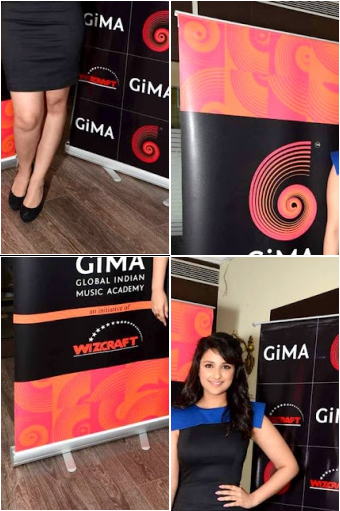


Task Prompt:
You are solving a 2x2 jigsaw puzzle. The puzzle pieces are currently scrambled. Your goal is to rearrange the pieces to recover the image. 

Available actions:
1. 'swap': Swap two pieces by specifying their coordinates. Format: `('swap', ((row1, col1), (row2, col2)))` where coordinates start from (0,0) at the top-left corner.
2. 'reorder': Reorder all pieces at once. Format: `('reorder', [0, 1, 2, ..., 3])` where the list represents the desired order of pieces from top-left to bottom-right.
3. 'stop': End the puzzle solving session. Format: `('stop', 'stop')`

Please respond with exactly one action and its arguments in the specified format. For example:
- To swap two pieces: `('swap', ((0, 0), (1, 1)))`
- To reorder all pieces: `('reorder', [0, 1, 2, ..., 3])`
- To stop: `('stop', 'stop')`

Index-to-cell mapping (0-based rows/cols):
- Index = row * 2 + col.
- Row 0 covers indices 0..1, row 1 covers 2..3, etc.
Example for 2x2: (0,0)->0, (0,1)->1, (1,0)->2, (1,1)->3.



In [5]:
obs, info = env.reset()
print(f"Observation shape: {obs.shape}")
print(f"Current state: {env.unwrapped.current_state}")
print(f"Target state: {env.unwrapped.target_state}")

display(Image.fromarray(obs))
print(f"\nTask Prompt:\n{env.get_prompt()}")

## 3. Test Manual Actions - Swap

Action: ('swap', ((0, 0), (1, 1)))
Current state: [0, 1, 2, 3]
Proportion matched: 25.00%


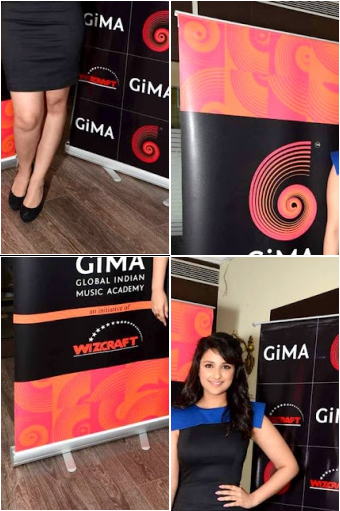

In [7]:
# Swap two pieces
action = "('swap', ((0, 0), (1, 1)))"
obs, reward, terminated, truncated, info = env.step(action)
print(f"Action: {action}")
print(f"Current state: {env.unwrapped.current_state}")
print(f"Proportion matched: {info['proportion_matched']:.2%}")
display(Image.fromarray(obs))

## 4. Test Solver - Reorder Strategy

Found 558128 images in /data/users/zwcolin/launch/current/gymnasium/envs/../../data/images
Initial scrambled state:
Current: [0, 1, 2, 3], Target: [2, 0, 3, 1]


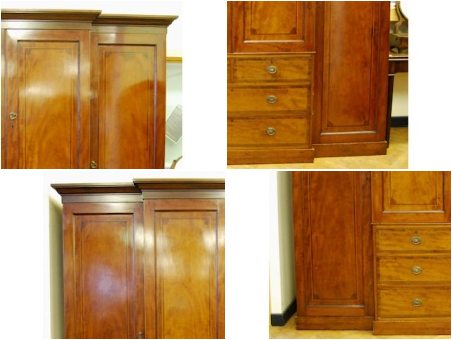


Solver actions: ["('reorder', [2, 0, 3, 1])", "('stop', 'stop')"]
Action: ('reorder', [2, 0, 3, 1])
Current state: [2, 0, 3, 1]
Action: ('stop', 'stop')
Current state: [2, 0, 3, 1]

✓ Puzzle solved! Reward: 1.0


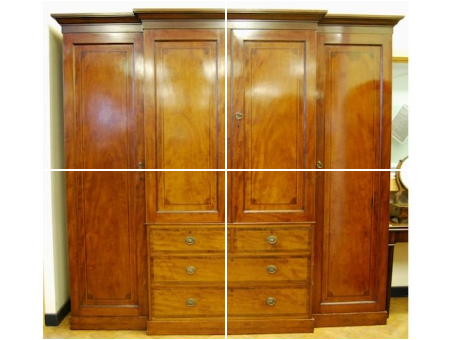

In [8]:
env = gym.make("jigsaw/easy", seed=100)
obs, info = env.reset()
print("Initial scrambled state:")
print(f"Current: {env.unwrapped.current_state}, Target: {env.unwrapped.target_state}")
display(Image.fromarray(obs))

# Get solver actions using reorder strategy
actions = env.solve(strategy="reorder")
print(f"\nSolver actions: {actions}")

# Execute solver actions
for action in actions:
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"Action: {action}")
    print(f"Current state: {env.unwrapped.current_state}")
    if terminated:
        print(f"\n✓ Puzzle solved! Reward: {reward}")
        display(Image.fromarray(obs))
        break

env.close()

## 5. Test Solver - Swap Strategy

Found 558128 images in /data/users/zwcolin/launch/current/gymnasium/envs/../../data/images
Initial state:


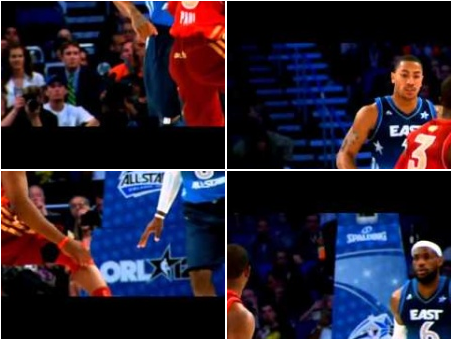


Solver generated 6 swap actions
Step 1: ('swap', ((0, 0), (0, 1)))


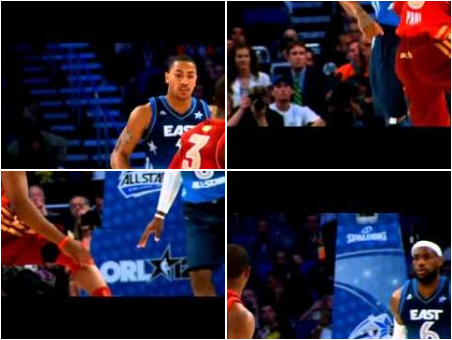

Step 2: ('swap', ((0, 1), (1, 1)))


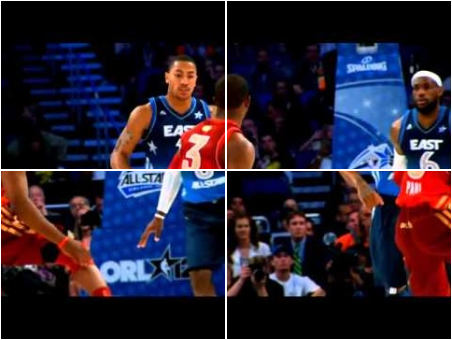

Step 3: ('swap', ((1, 0), (1, 1)))


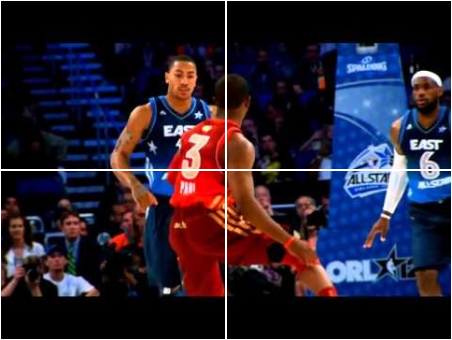

Step 6: ('stop', 'stop')
✓ Reward: 1.0


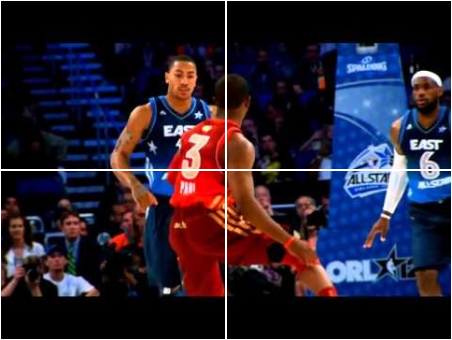

In [9]:
env = gym.make("jigsaw/easy", seed=200)
obs, info = env.reset()
print("Initial state:")
display(Image.fromarray(obs))

# Get solver actions using swap strategy with minimum 5 steps
actions = env.solve(strategy="swap", num_steps=5)
print(f"\nSolver generated {len(actions)} swap actions")

# Execute solver actions
for i, action in enumerate(actions):
    obs, reward, terminated, truncated, info = env.step(action)
    if i < 3 or terminated:  # Show first 3 and final
        print(f"Step {i+1}: {action}")
        if terminated:
            print(f"✓ Reward: {reward}")
            display(Image.fromarray(obs))
        elif i < 3:
            display(Image.fromarray(obs))

env.close()

## 6. Test Hard Difficulty (3x3)

Found 558128 images in /data/users/zwcolin/launch/current/gymnasium/envs/../../data/images
Hard difficulty - 3x3 grid
Current: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Target: [7, 8, 1, 2, 6, 4, 5, 0, 3]


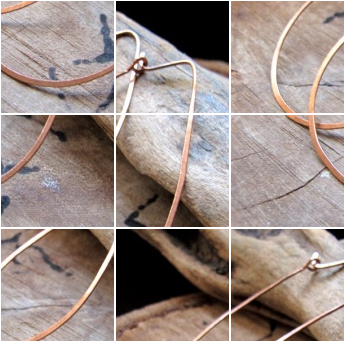

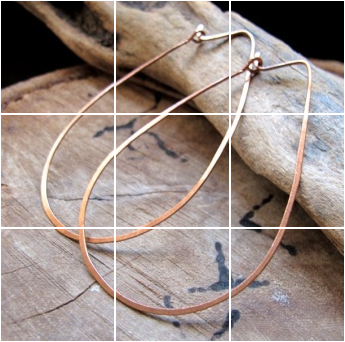

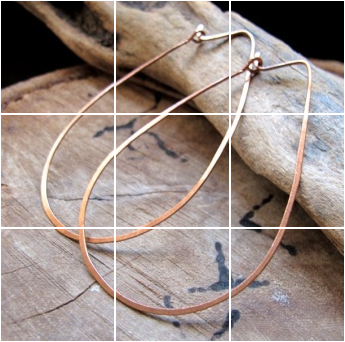

Solved! Reward: 1.0


In [13]:
env_hard = gym.make("jigsaw/hard", seed=42)
obs, info = env_hard.reset()
print(f"Hard difficulty - {env_hard.unwrapped.num_rows}x{env_hard.unwrapped.num_cols} grid")
print(f"Current: {env_hard.unwrapped.current_state}")
print(f"Target: {env_hard.unwrapped.target_state}")
display(Image.fromarray(obs))

# Solve it
actions = env_hard.solve(strategy="reorder")
for action in actions:
    obs, reward, terminated, truncated, info = env_hard.step(action)
    display(Image.fromarray(obs))
    if terminated:
        print(f"Solved! Reward: {reward}")
        break

env_hard.close()